<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/17_Model_Evalution/Regression_Metrics/1_Regression_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Metrics

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split



In [12]:
df = pd.read_csv("/content/placement_linear.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


<Axes: xlabel='cgpa', ylabel='package'>

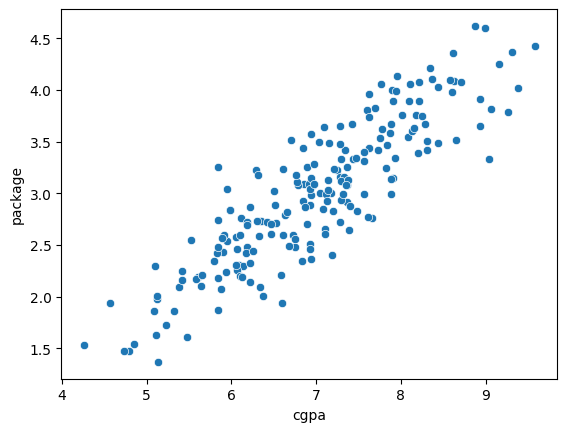

In [13]:
sns.scatterplot(data=df, x='cgpa', y='package')

In [ ]:
x = df.iloc[:,0].values.reshape(-1,1)
y = df.iloc[:,1].values.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)
X_train

In [26]:
from sklearn.linear_model import LinearRegression


lr = LinearRegression()

lr.fit(X_train, y_train)





LinearRegression()

<Axes: xlabel='cgpa', ylabel='package'>

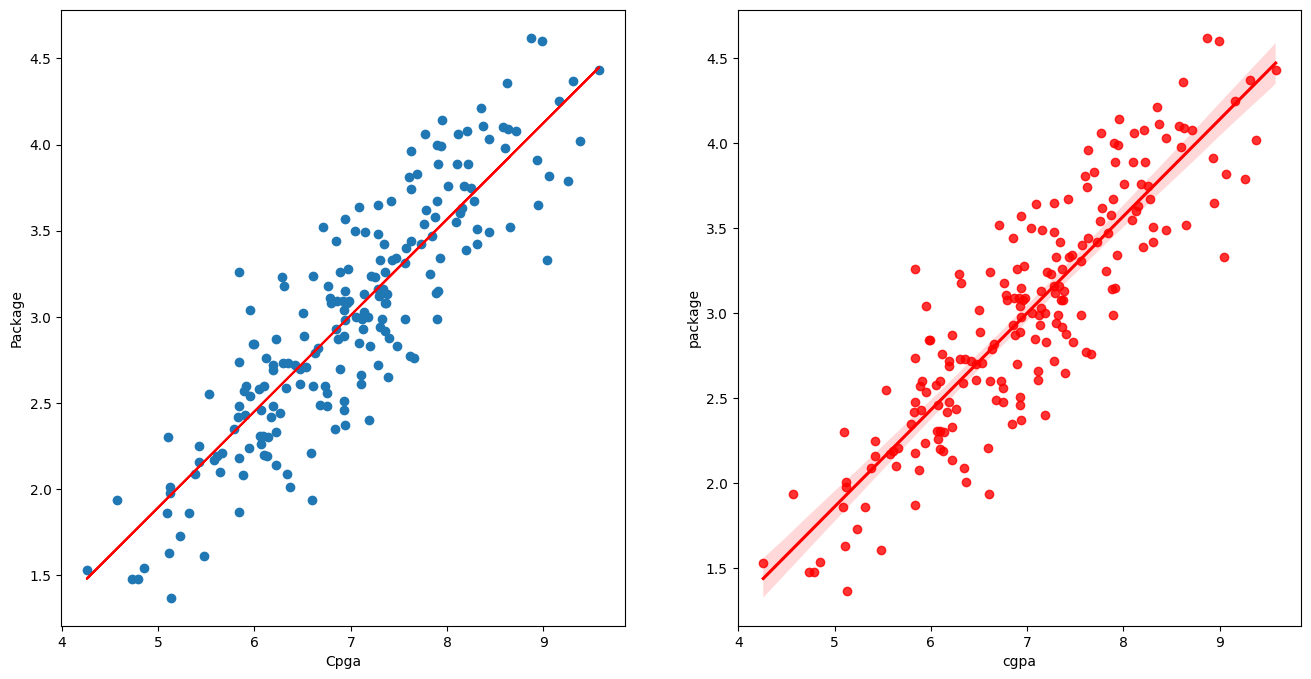

In [39]:
fig = plt.figure(figsize=(16, 8))
plt.subplot(1,2,1)
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('Cpga')
plt.ylabel('Package')

plt.subplot(1,2,2)
sns.regplot(data=df, x='cgpa', y='package', color='red')

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

In [50]:
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616
R2 0.780730147510384


In [48]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [51]:
# adjested R2 score
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

# Change Adjusted R2 Score with adding random column

In [52]:
# how to vary adjusted r2 score

new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1

,cgpa,package,random_feature
0,6.89,3.26,0.734555
1,5.12,1.98,0.828727
2,7.82,3.25,0.812823
3,7.42,3.67,0.132838
4,6.94,3.57,0.429313
...,...,...,...
195,6.93,2.46,0.878713
196,5.89,2.57,0.064559
197,7.21,3.24,0.665345
198,7.63,3.96,0.246473


<Axes: xlabel='random_feature', ylabel='package'>

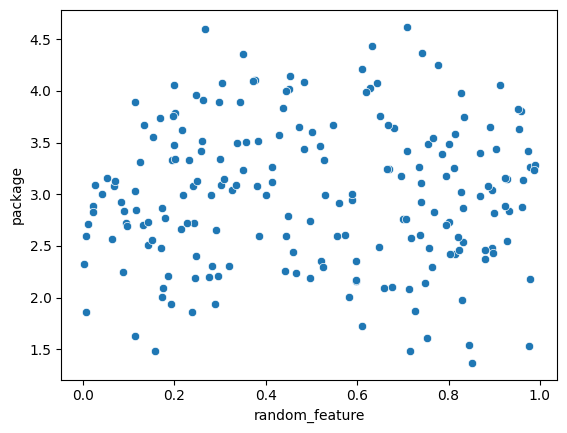

In [53]:
sns.scatterplot(data=new_df1, x='random_feature', y='package') # random pattern


In [54]:
new_df1.head(2)

,cgpa,package,random_feature
0,6.89,3.26,0.734555
1,5.12,1.98,0.828727


In [58]:
x = new_df1.drop('package',axis=1)
y = new_df1.iloc[:,[1]]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [60]:
lr = LinearRegression()

lr.fit(X_train, y_train)


LinearRegression()

In [61]:
y_pred = lr.predict(X_test)

In [62]:
print('R2 score', r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7861666081305515


In [63]:
1 - ((1-r2)*(40-1)/(40-1-2)) # adjusted r2 score

0.7746080464078786

# Change Adjusted R2 Score with adding related column

In [64]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)
new_df2.head()

,cgpa,package,iq
0,6.89,3.26,2.16
1,5.12,1.98,2.68
2,7.82,3.25,3.35
3,7.42,3.67,3.97
4,6.94,3.57,3.87


<Axes: xlabel='iq', ylabel='package'>

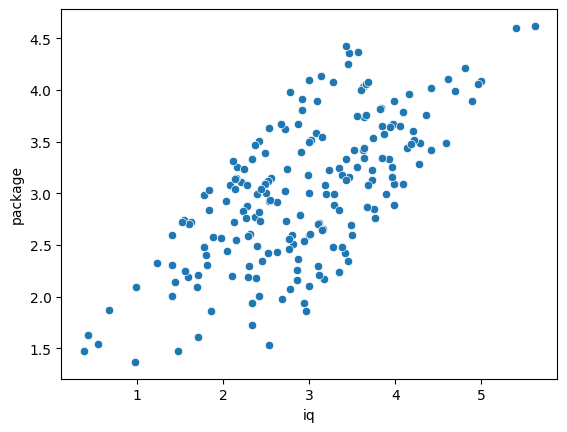

In [66]:
sns.scatterplot(data=new_df2, x='iq', y='package')

In [67]:
x = new_df2.drop('package',axis=1)
y = new_df2.iloc[:,[1]]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [68]:
lr = LinearRegression()

lr.fit(X_train, y_train)


LinearRegression()

In [69]:
y_pred = lr.predict(X_test)

In [70]:
print('R2 score', r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8236221959752471


In [71]:
1 - ((1-r2)*(40-1)/(40-1-2)) # adjusted r2 score

0.8140882606225578